# Clustering Jerárquico Aglomerativo (HAC)
## Dataset: Calificaciones de Estudiantes

El **HAC** agrupa observaciones similares construyendo una jerarquía ascendente visualizada
en un **dendrograma**. Con solo 10 estudiantes y 5 materias, este dataset permite ver el
árbol completo con los nombres — ideal para interpretar los resultados de forma intuitiva.

### Flujo de trabajo
```
mf.HAC(path, num)          # 1. Cargar datos (modo 3: sep=';', decimal=',')
    ↓ métodos EDA heredados # 2. Limpiar y preparar
hac.ajustar()              # 3. Ajustar el modelo
hac.plot_*()               # 4. Visualizar resultados
```

## 1. Importación de librerías

In [1]:
import sys
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
import pckEDA as mf

%matplotlib inline
print('pckEDA cargado correctamente')
print('Clase HAC disponible:', mf.HAC)

pckEDA cargado correctamente
Clase HAC disponible: <class 'pckEDA.no_supervisado.hac.HAC'>


## 2. Carga de datos

`HAC` hereda de `AnalisisDatosExploratorio`. El archivo usa formato español
(separador `;`, decimal `,`), por lo que se utiliza el **modo 3**.

In [2]:
hac = mf.HAC('../datasets/ejemplo_estudiantes.csv', 3, n_clusters=3, metodo='ward')

hac.mostrarTamaño()
hac.muestraTiposDeDatos()

Tamaño del DataFrame: (10, 5)
Matematicas    float64
Ciencias       float64
Espanol        float64
Historia       float64
EdFisica       float64
dtype: object


## 3. Preprocesamiento con métodos heredados del EDA

El dataset ya es completamente numérico — no requiere codificación de categóricas.
Solo verificamos que no haya nulos y conservamos columnas numéricas.

In [3]:
hac.eliminarNulos()
hac.analisisNumerico()
print(f'Columnas para el modelo: {list(hac.df.columns)}')
print(f'Observaciones          : {len(hac.df)}')
hac.df

Valores nulos antes: 0 en 10 filas.
Matematicas    0
Ciencias       0
Espanol        0
Historia       0
EdFisica       0
dtype: int64
Valores nulos después: 0 en 10 filas.
Columnas para el modelo: ['Matematicas', 'Ciencias', 'Espanol', 'Historia', 'EdFisica']
Observaciones          : 10


,Matematicas,Ciencias,Espanol,Historia,EdFisica
Lucia,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Ines,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Andres,6.0,6.0,7.8,8.9,7.3
Ana,7.8,9.6,7.7,8.0,6.5
Carlos,6.3,6.4,8.2,9.0,7.2
Jose,7.9,9.7,7.5,8.0,6.0
Sonia,6.0,6.0,6.5,5.5,8.7
Maria,6.8,7.2,8.7,9.0,7.0


## 4. Ajuste del modelo HAC

In [4]:
hac.ajustar()

print(f'Método de enlace      : {hac.metodo}')
print(f'Número de clusters    : {hac.n_clusters}')
print(f'Correlación cofenética: {hac.cophenet_corr:.4f}')
print()
import pandas as pd
print('Distribución de observaciones por cluster:')
print(pd.Series(hac.etiquetas, index=hac.df.index).sort_values().to_string())

Método de enlace      : ward
Número de clusters    : 3
Correlación cofenética: 0.9142

Distribución de observaciones por cluster:
Luis      1
Sonia     1
Pedro     2
Ines      2
Ana       2
Jose      2
Lucia     3
Andres    3
Carlos    3
Maria     3


> **Correlación cofenética ≥ 0.70** → clustering aceptable. **≥ 0.80** → muy buena calidad.

## 5. Visualizaciones

### 5.1 Dendrograma

Con 10 estudiantes, `max_hojas=10` muestra el árbol completo con todos los nombres.

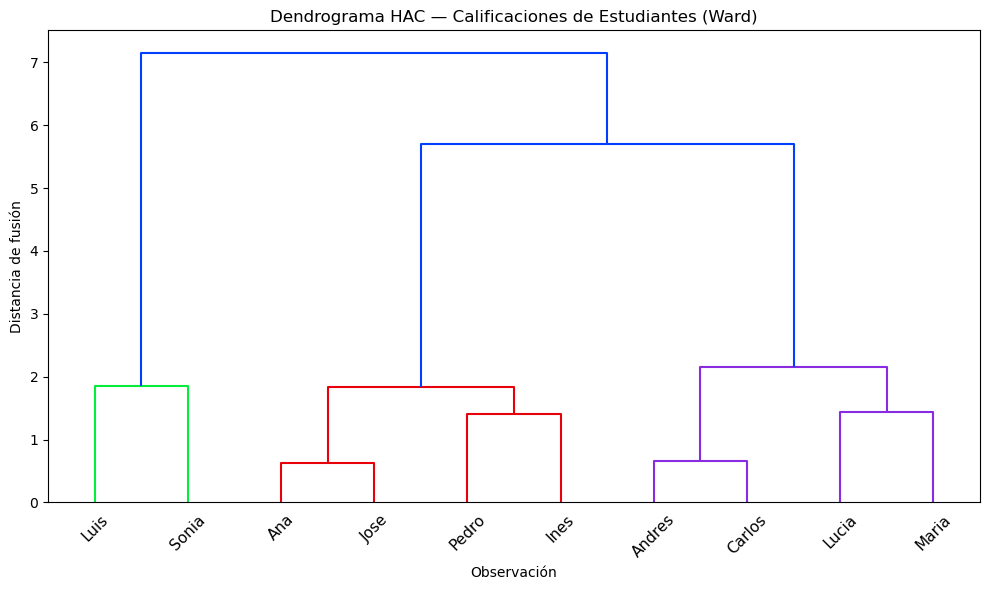

In [5]:
plt.figure(figsize=(10, 6))
hac.plot_dendrograma(max_hojas=10, titulo='Dendrograma HAC — Calificaciones de Estudiantes (Ward)')
plt.tight_layout()
plt.show()

### 5.2 Mapa de calor — Perfil de clusters

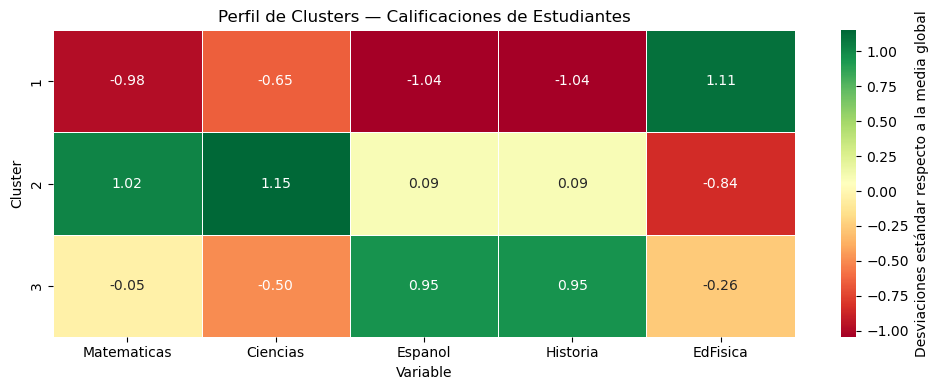

In [6]:
plt.figure(figsize=(10, 4))
hac.plot_mapa_calor(titulo='Perfil de Clusters — Calificaciones de Estudiantes')
plt.tight_layout()
plt.show()

### 5.3 Distribución de observaciones por cluster

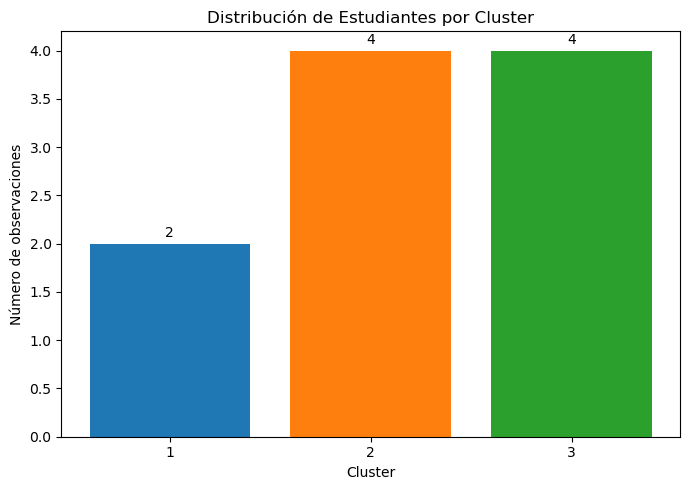

In [7]:
plt.figure(figsize=(7, 5))
hac.plot_distribucion(titulo='Distribución de Estudiantes por Cluster')
plt.tight_layout()
plt.show()

### 5.4 Diagramas de dispersión por cluster

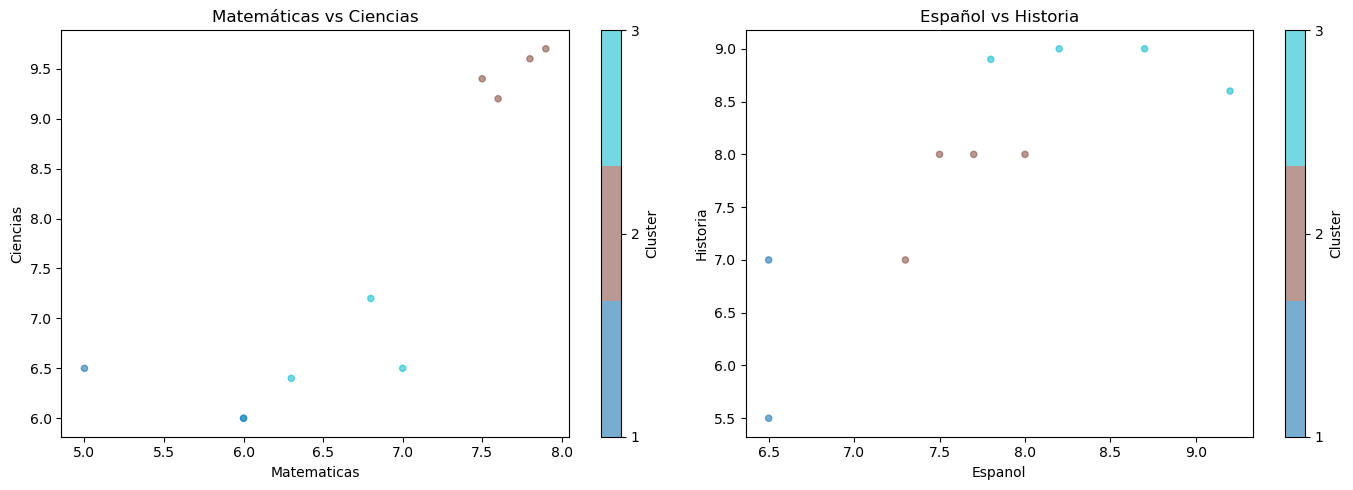

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
hac.plot_dispersion('Matematicas', 'Ciencias', titulo='Matemáticas vs Ciencias')

plt.sca(axes[1])
hac.plot_dispersion('Espanol', 'Historia', titulo='Español vs Historia')

plt.tight_layout()
plt.show()

### 5.5 Barras de centroides por cluster

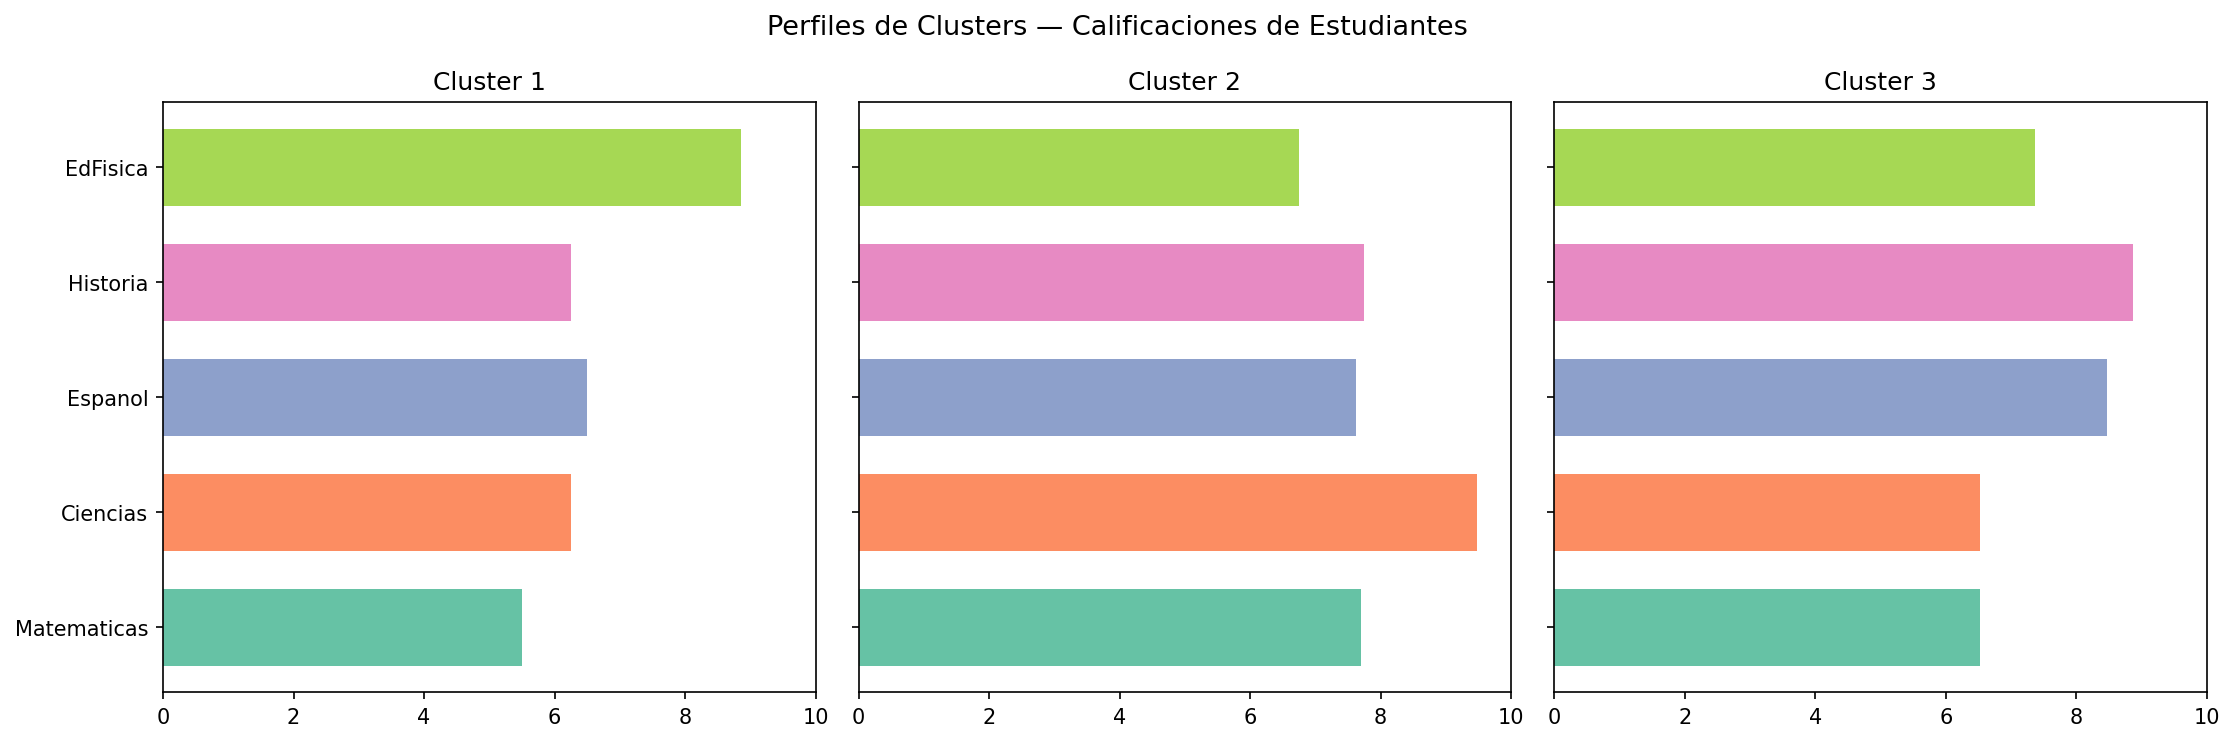

In [9]:
hac.plot_barras(
    titulo='Perfiles de Clusters — Calificaciones de Estudiantes',
    escala=False
)
plt.show()

### 5.6 Gráfico radar de clusters

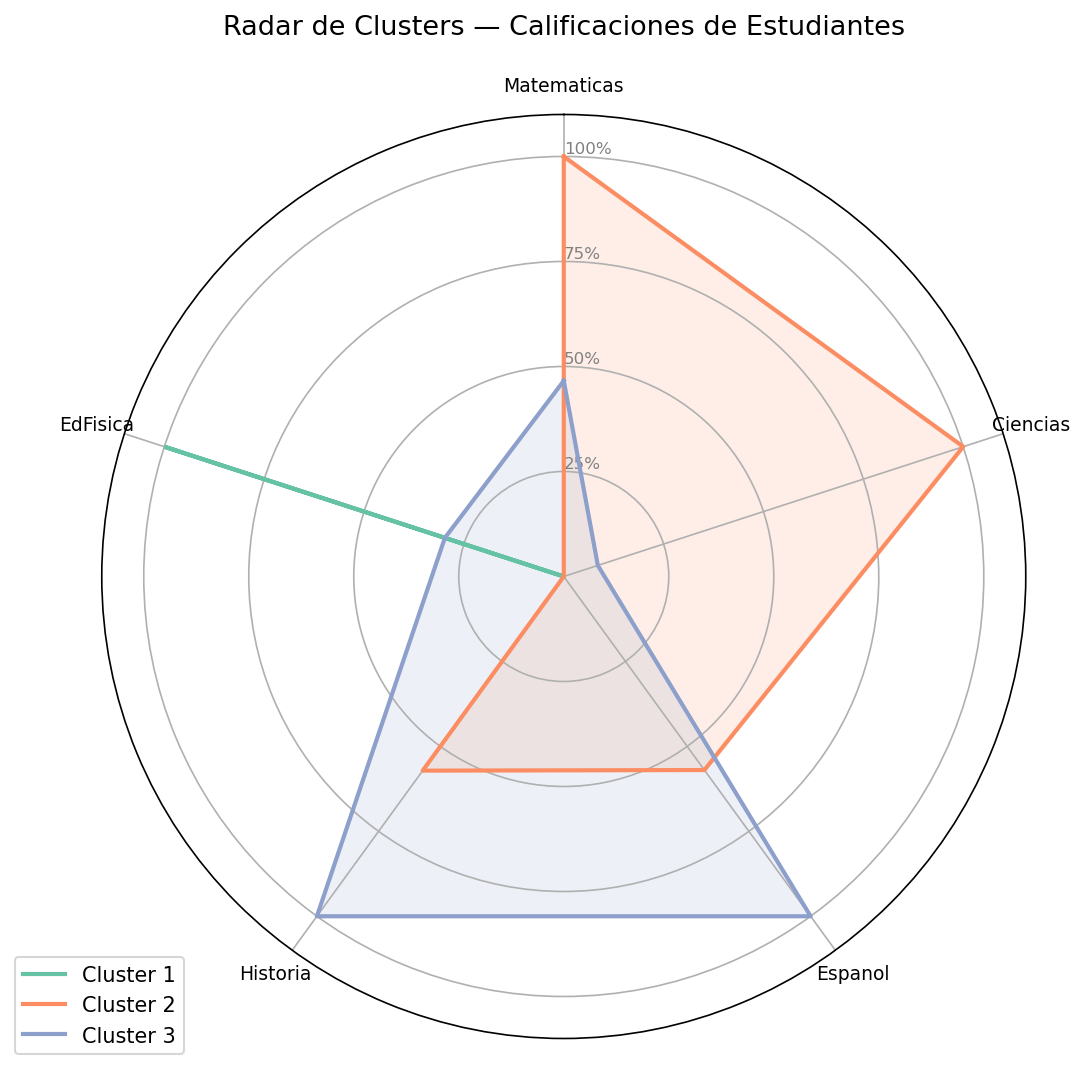

In [10]:
hac.plot_radar(titulo='Radar de Clusters — Calificaciones de Estudiantes')
plt.show()

## 6. Resumen estadístico por cluster

In [11]:
hac.resumen.style.background_gradient(cmap='Blues', axis=0).format('{:.2f}')

,Matematicas,Ciencias,Espanol,Historia,EdFisica
cluster,,,,,
1,5.50,6.25,6.50,6.25,8.85
2,7.70,9.47,7.62,7.75,6.75
3,6.53,6.53,8.47,8.88,7.38


## 7. Comparación de métodos de enlace

Valores nulos antes: 0 en 10 filas.
Matematicas    0
Ciencias       0
Espanol        0
Historia       0
EdFisica       0
dtype: int64
Valores nulos después: 0 en 10 filas.
Valores nulos antes: 0 en 10 filas.
Matematicas    0
Ciencias       0
Espanol        0
Historia       0
EdFisica       0
dtype: int64
Valores nulos después: 0 en 10 filas.
Valores nulos antes: 0 en 10 filas.
Matematicas    0
Ciencias       0
Espanol        0
Historia       0
EdFisica       0
dtype: int64
Valores nulos después: 0 en 10 filas.
Valores nulos antes: 0 en 10 filas.
Matematicas    0
Ciencias       0
Espanol        0
Historia       0
EdFisica       0
dtype: int64
Valores nulos después: 0 en 10 filas.


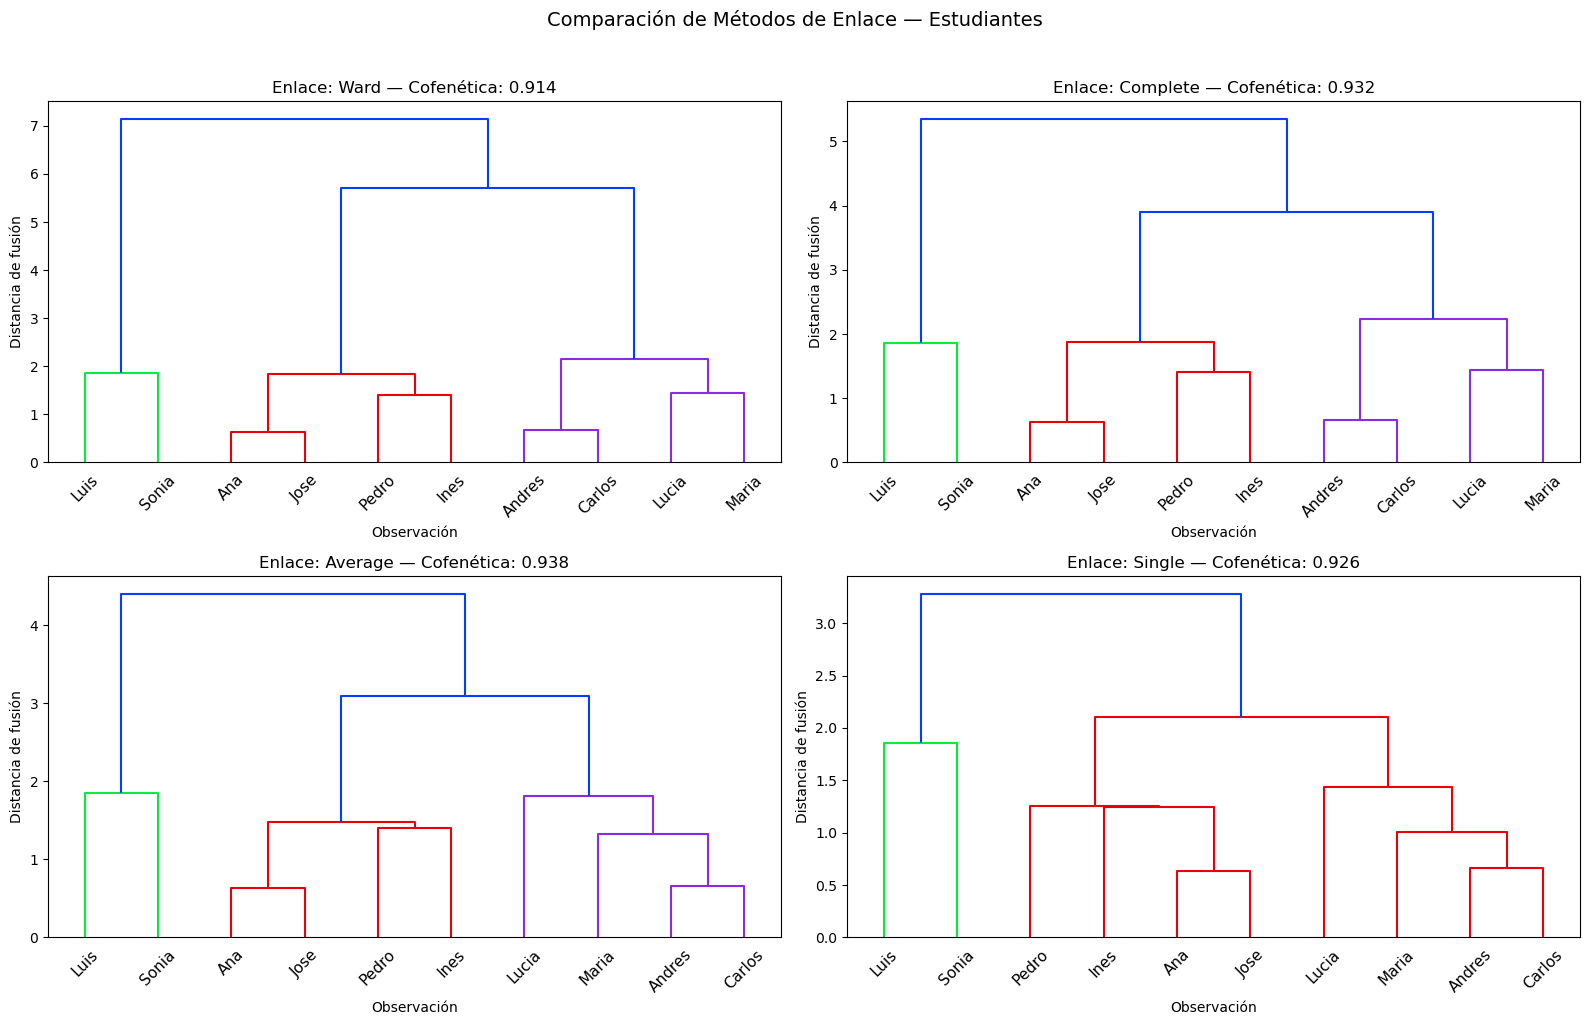

In [12]:
metodos = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, metodo in zip(axes.ravel(), metodos):
    h = mf.HAC('../datasets/ejemplo_estudiantes.csv', 3, n_clusters=3, metodo=metodo)
    h.eliminarNulos()
    h.analisisNumerico()
    h.ajustar()
    plt.sca(ax)
    h.plot_dendrograma(
        max_hojas=10,
        titulo=f'Enlace: {metodo.capitalize()} — Cofenética: {h.cophenet_corr:.3f}'
    )

plt.suptitle('Comparación de Métodos de Enlace — Estudiantes', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Conclusiones

- El dendrograma con nombres permite identificar directamente qué estudiantes son más similares en su perfil de calificaciones.
- El **mapa de calor** muestra qué materias caracterizan a cada cluster (e.g. un grupo fuerte en ciencias, otro en humanidades).
- Con datasets pequeños, el **método Ward** sigue siendo el más equilibrado, pero la diferencia entre métodos es más visible que en datasets grandes.
- La **correlación cofenética** indica qué tan bien el árbol representa las distancias reales entre estudiantes.